In [1]:
%pip install -e .. -q


Note: you may need to restart the kernel to use updated packages.


DEPRECATION: pytorch-lightning 1.7.7 has a non-standard dependency specifier torch>=1.9.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


# HJB Solver Validation: Frozen-Path Convergence

Validate that the numerical HJB solver (`NumericalErgodicMM`) reproduces the closed-form Gueant optimal quotes (`ErgodicMM`) as the internal solver grid is refined.

To remove backtest path-dependency, the analytical agent is run once per segment to fix the realised (mid, sigma, inventory) trajectory. Both agents are then evaluated at every frozen state, so inventory cannot drift and only the solver resolution varies.

Two views, each aggregated over many 8-hour sim segments with 95% confidence intervals:

1. Discretized quotes: exact tick-match percentage vs solver tick.
2. Continuous offsets (pre-rounding): RMSE of the offset error vs solver tick, contrasted with the tick-rounded RMSE which saturates at the market-tick quantization floor.


In [ ]:
import sqlite3
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from research_core.classes import ErgodicMM, resolve_data_path
from research_core.classes.mm_backtest_parallel import plan_8h_segments
from research_core.classes.hjb_validation import (
    run_frozen_path_convergence_parallel,
    aggregate_frozen_convergence,
    convergence_order_estimate,
    frozen_path_segment_metrics,
    plot_frozen_agreement_ci,
    plot_frozen_offset_rmse_ci,
)

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.figsize": (6.5, 4.5), "axes.grid": True})


## 1. Configuration


In [3]:
sim_tick = 0.05
sim_bt_size = 1000
gamma = 0.05

adapted_db = resolve_data_path("sim_test_adapted.sqlite")
erg_vol_mode = "ewma_event"

n_segments = 48
segment_hours = 8.0
n_jobs = 12
sim_source_days = [f"sim{i:05d}" for i in range(60)]

solver_ticks = [0.05, 0.025, 0.01, 0.005, 0.001, 0.0005, 0.0001]
base_solver_kw = dict(
    max_delta=0.2,
    delta_lo=0.0,
    max_iter=10_000,
    tol=1e-4,
    poisson_tau=1.0,
)

output_csv = resolve_data_path("hjb_validation/frozen_convergence.csv")

print(f"Sim DB: {adapted_db.name}  exists={adapted_db.is_file()}")
print(f"Segments: {n_segments} x {segment_hours:.0f}h over {n_jobs} workers")
print(f"Solver ticks: {solver_ticks}")


Sim DB: sim_test_adapted.sqlite  exists=True
Segments: 48 x 8h over 12 workers
Solver ticks: [0.05, 0.025, 0.01, 0.005, 0.001, 0.0005, 0.0001]


## 2. Calibrate ergodic parameters

Both agents share the same calibrated parameters and EWMA event volatility (`vol_mode='ewma_event'`), so any quote discrepancy is attributable to the solver discretization alone.


In [4]:
conn = sqlite3.connect(str(adapted_db))
sim_mo_df = pd.read_sql("SELECT * FROM mo_orders", conn)
sim_orders_df = pd.read_sql(
    "SELECT best_bid, best_ask FROM orders ORDER BY day, timestamp", conn
)
conn.close()

erg_params_sim = ErgodicMM.calibrate(sim_mo_df, sim_orders_df, tick_size=sim_tick)
erg_params_sim = {**erg_params_sim, "vol_mode": erg_vol_mode}
print(f"erg_params_sim = {erg_params_sim}")


ErgodicMM.calibrate:
  calibrate_k: fitted k = 0.7909  (from 10 levels, 1808162 MOs)
  k conversion: 0.7909/tick -> 15.8177/PLN (tick_size=0.05)
  calibrate_vol_halflife: best half-life = 200  (MSE = 3.54e-14, from 5 candidates)
  calibrate_A: 1808162 MOs across 4743.2h -> A = 0.052946 /sec (per side)
  -> {'k': 15.817654724706927, 'vol_halflife': 200, 'tick_size': 0.05, 'intensity_a': 0.05294583377424301}
erg_params_sim = {'k': 15.817654724706927, 'vol_halflife': 200, 'tick_size': 0.05, 'intensity_a': 0.05294583377424301, 'vol_mode': 'ewma_event'}


## 3. Plan segments


In [5]:
segments = plan_8h_segments(
    adapted_db, sim_source_days,
    n_days=n_segments, segment_hours=segment_hours,
)
n_days_used = len({s["day"] for s in segments})
print(f"Planned {len(segments)} segments from {n_days_used} sim days")
print(f"First: {segments[0]['label']}   Last: {segments[-1]['label']}")


Planned 48 segments from 6 sim days
First: sim00000_seg00   Last: sim00005_seg01


## 4. Frozen-path convergence study

Each segment runs the analytical agent once to fix the state trajectory, then evaluates both agents at every frozen state across all solver ticks. The finest ticks dominate runtime; results stream to `OUTPUT_CSV` so the run is crash resilient. Reduce `SOLVER_TICKS` for a quick pass.


In [6]:
t0 = time.perf_counter()
print(f"Starting {n_segments} segments x {len(solver_ticks)} ticks "
      f"on {n_jobs} workers ...", flush=True)

df_long = run_frozen_path_convergence_parallel(
    segments,
    db_path=adapted_db,
    gamma=gamma,
    erg_params=erg_params_sim,
    size=sim_bt_size,
    solver_ticks=solver_ticks,
    base_solver_kw=base_solver_kw,
    tick_size=sim_tick,
    hawkes=True,
    load_book_state=True,
    skip_opening=False,
    n_jobs=n_jobs,
    output_csv=output_csv,
)

elapsed = time.perf_counter() - t0
print(f"\nDone in {elapsed/60:.1f} min. Collected {len(df_long)} rows "
      f"({df_long['label'].nunique()} segments x {df_long['solver_tick'].nunique()} ticks)")
df_long.head()


Starting 48 segments x 7 ticks on 12 workers ...
[preload] sim00000: 969,574 rows
[preload] sim00001: 970,190 rows
[preload] sim00002: 969,928 rows
[preload] sim00003: 969,730 rows
[preload] sim00004: 969,773 rows
[preload] sim00005: 969,968 rows
Dispatching 48 segments on 12 workers ...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.


  [sim00001_seg00] tick=5.0e-02 ask=78.9% rmse_c=1.52e-02 [50.8s]
  [sim00000_seg00] tick=5.0e-02 ask=69.2% rmse_c=1.65e-02 [46.6s]
  [sim00000_seg04] tick=5.0e-02 ask=80.3% rmse_c=1.47e-02 [16.4s]
  [sim00001_seg01] tick=5.0e-02 ask=80.6% rmse_c=1.37e-02 [39.4s]
  [sim00000_seg02] tick=5.0e-02 ask=78.1% rmse_c=1.47e-02 [29.6s]
  [sim00000_seg05] tick=5.0e-02 ask=79.6% rmse_c=1.49e-02 [12.1s]
  [sim00001_seg02] tick=5.0e-02 ask=75.5% rmse_c=1.51e-02 [37.6s]
  [sim00000_seg03] tick=5.0e-02 ask=79.2% rmse_c=1.48e-02 [25.4s]
  [sim00000_seg06] tick=5.0e-02 ask=78.8% rmse_c=1.42e-02 [13.1s]
  [sim00000_seg01] tick=5.0e-02 ask=79.3% rmse_c=1.43e-02 [57.0s]
  [sim00000_seg07] tick=5.0e-02 ask=80.1% rmse_c=1.38e-02 [10.5s]  [sim00000_seg08] tick=5.0e-02 ask=79.3% rmse_c=1.52e-02 [8.9s]

  [sim00001_seg00] tick=2.5e-02 ask=75.4% rmse_c=7.17e-03 [5.0s]
  [sim00000_seg00] tick=2.5e-02 ask=70.8% rmse_c=7.08e-03 [4.5s]
  [sim00001_seg01] tick=2.5e-02 ask=82.6% rmse_c=7.59e-03 [6.6s]
  [sim00000_se

[Parallel(n_jobs=12)]: Done  35 out of  48 | elapsed: 120.9min remaining: 44.9min


  [sim00003_seg08] tick=1.0e-03 ask=99.9% rmse_c=4.75e-04 [308.0s]
  [sim00004_seg05] tick=5.0e-03 ask=98.7% rmse_c=1.56e-03 [115.7s]
  [sim00004_seg06] tick=5.0e-03 ask=97.7% rmse_c=1.70e-03 [105.7s]
  [sim00004_seg02] tick=5.0e-04 ask=97.9% rmse_c=5.68e-04 [276.1s]
  [sim00004_seg07] tick=5.0e-02 ask=77.2% rmse_c=1.47e-02 [99.6s]
  [sim00004_seg00] tick=1.0e-04 ask=99.8% rmse_c=3.78e-04 [283.1s]
[sim00004_seg00] DONE 7 ticks in 1353s total
  [sim00004_seg04] tick=1.0e-03 ask=98.0% rmse_c=4.74e-04 [221.1s]
  [sim00004_seg01] tick=5.0e-04 ask=99.5% rmse_c=4.37e-04 [414.8s]
  [sim00005_seg00] tick=5.0e-02 ask=74.4% rmse_c=1.61e-02 [57.2s]
  [sim00004_seg07] tick=2.5e-02 ask=74.9% rmse_c=6.73e-03 [72.5s]
  [sim00005_seg00] tick=2.5e-02 ask=74.3% rmse_c=7.04e-03 [56.8s]
  [sim00004_seg03] tick=5.0e-04 ask=99.9% rmse_c=8.59e-04 [348.3s]
  [sim00004_seg05] tick=1.0e-03 ask=100.0% rmse_c=5.81e-04 [321.3s]
  [sim00004_seg07] tick=1.0e-02 ask=96.5% rmse_c=2.77e-03 [134.5s]
  [sim00005_seg00] t

[Parallel(n_jobs=12)]: Done  45 out of  48 | elapsed: 147.6min remaining:  9.8min


  [sim00004_seg07] tick=5.0e-04 ask=99.0% rmse_c=8.86e-04 [329.5s]
  [sim00004_seg08] tick=1.0e-03 ask=99.5% rmse_c=5.87e-04 [254.2s]
  [sim00005_seg01] tick=1.0e-03 ask=100.0% rmse_c=5.06e-04 [172.1s]
  [sim00004_seg08] tick=5.0e-04 ask=99.6% rmse_c=4.94e-04 [208.7s]
  [sim00004_seg07] tick=1.0e-04 ask=99.4% rmse_c=8.71e-04 [265.8s]
[sim00004_seg07] DONE 7 ticks in 1767s total
  [sim00005_seg01] tick=5.0e-04 ask=100.0% rmse_c=4.47e-04 [219.6s]
  [sim00004_seg08] tick=1.0e-04 ask=99.8% rmse_c=4.59e-04 [274.7s]
[sim00004_seg08] DONE 7 ticks in 1639s total
  [sim00005_seg01] tick=1.0e-04 ask=100.0% rmse_c=4.11e-04 [244.2s]
[sim00005_seg01] DONE 7 ticks in 1532s total
  done: 48/48 segments


[Parallel(n_jobs=12)]: Done  48 out of  48 | elapsed: 156.7min finished



Done in 158.8 min. Collected 336 rows (48 segments x 7 ticks)


,label,solver_tick,n_quotes,ask_exact_pct,bid_exact_pct,rmse_disc,mae_disc,rmse_cont,mae_cont,elapsed_s
0,sim00000_seg00,0.050,933,69.239014,72.775991,0.026922,0.014496,0.016533,0.015021,46.557764
1,sim00000_seg00,0.025,933,70.846731,72.347267,0.026647,0.014202,0.007077,0.006105,4.497571
2,sim00000_seg00,0.010,933,98.285102,96.784566,0.007850,0.001233,0.002697,0.002347,10.107055
3,sim00000_seg00,0.005,933,94.962487,92.926045,0.012304,0.003028,0.001606,0.001414,20.074672
4,sim00000_seg00,0.001,933,99.571275,97.427653,0.006125,0.000750,0.000399,0.000323,68.428374


## 5. Aggregate and plot


In [7]:
df_agg = aggregate_frozen_convergence(df_long, confidence=0.95)
display(df_agg[[
    "solver_tick", "n_segments",
    "ask_exact_pct_mean", "bid_exact_pct_mean",
    "rmse_cont_mean", "rmse_disc_mean",
    "avg_iters_mean", "avg_solve_time_ms_mean",
]])

print("\nPercentile worst |δ_cont| difference (PLN), mean across segments:")
pcols = [c for c in df_agg.columns if c.startswith("p9") or c == "max_cont_mean"]
display(df_agg[["solver_tick"] + pcols])


,solver_tick,n_segments,ask_exact_pct_mean,bid_exact_pct_mean,rmse_cont_mean,rmse_disc_mean
0,0.0001,48,99.445767,99.552159,0.000478,0.002978
1,0.0005,48,99.521442,99.556420,0.000499,0.002883
2,0.0010,48,99.474035,99.537155,0.000562,0.003101
3,0.0050,48,97.080318,97.016873,0.001647,0.008239
4,0.0100,48,97.892482,97.778145,0.002506,0.007092
5,0.0250,48,77.140483,77.429019,0.007113,0.023800
6,0.0500,48,79.211920,79.066816,0.014577,0.022769


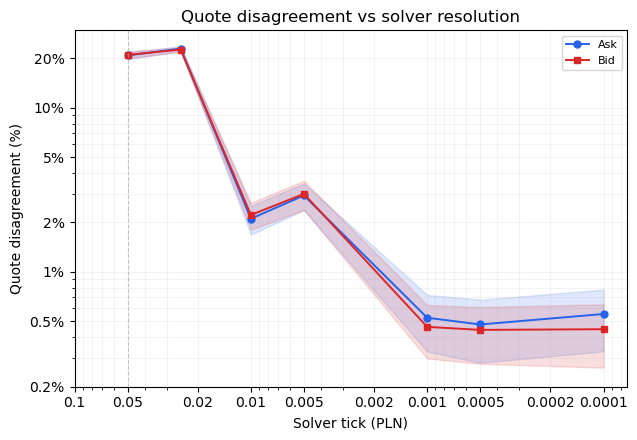

In [24]:
fig = plot_frozen_agreement_ci(df_agg, sim_tick)
plt.show()


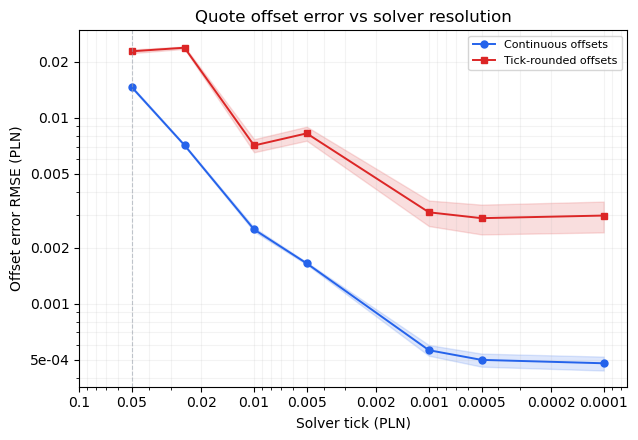

In [27]:
fig = plot_frozen_offset_rmse_ci(df_agg, sim_tick)
plt.show()


In [28]:
order_cont = convergence_order_estimate(df_agg, error_col="rmse_cont_mean")
ordered = df_agg.sort_values("solver_tick")
finest = ordered.iloc[0]

print("Frozen-path convergence summary")
print(f"  Segments: {int(finest['n_segments'])}, solver ticks: {df_agg['solver_tick'].nunique()}")
print(f"  Continuous-offset RMSE convergence order (log-log slope): "
      f"{order_cont['order']:.2f} (R^2 = {order_cont['r_squared']:.3f})")
print(f"  Finest tick {finest['solver_tick']:.0e}:")
print(f"    ask match {finest['ask_exact_pct_mean']:.2f}% "
      f"[{finest['ask_exact_pct_lo']:.2f}, {finest['ask_exact_pct_hi']:.2f}]")
print(f"    bid match {finest['bid_exact_pct_mean']:.2f}% "
      f"[{finest['bid_exact_pct_lo']:.2f}, {finest['bid_exact_pct_hi']:.2f}]")
print(f"    continuous RMSE {finest['rmse_cont_mean']:.2e} PLN, "
      f"tick-rounded RMSE {finest['rmse_disc_mean']:.2e} PLN")
print(f"    avg iterations/solve: {finest['avg_iters_mean']:.1f}, "
      f"avg solve time: {finest['avg_solve_time_ms_mean']:.3f} ms")
print(f"    worst |Δ| percentiles:  p95={finest['p95_cont_mean']:.2e}  "
      f"p99={finest['p99_cont_mean']:.2e}  p99.9={finest['p99_9_cont_mean']:.2e}  "
      f"max={finest['max_cont_mean']:.2e}")


Frozen-path convergence summary
  Segments: 48, solver ticks: 7
  Continuous-offset RMSE convergence order (log-log slope): 0.57 (R^2 = 0.887)
  Finest tick 1e-04:
    ask match 99.45% [99.22, 99.67]
    continuous RMSE 4.78e-04 PLN, tick-rounded RMSE 2.98e-03 PLN


## 6. Warm-start efficiency: cold vs warm on a single segment

To quantify the value of warm-starting `phi` between consecutive solves, we re-run a single segment with `warm_start=False` (phi reset to zero before every quote) and compare iterations, solve time, and accuracy against the default warm-started run.

In [ ]:
test_seg = segments[0]
common_kw = dict(
    db_path=adapted_db,
    gamma=gamma,
    erg_params=erg_params_sim,
    size=sim_bt_size,
    solver_ticks=solver_ticks,
    base_solver_kw=base_solver_kw,
    tick_size=sim_tick,
    hawkes=True,
    load_book_state=True,
    skip_opening=False,
)

print(f"Segment: {test_seg['label']}")

print("\n--- WARM START (default) ---")
rows_warm = frozen_path_segment_metrics(test_seg, **common_kw, warm_start=True)

print("\n--- COLD START (phi reset every quote) ---")
rows_cold = frozen_path_segment_metrics(test_seg, **common_kw, warm_start=False)

df_warm = pd.DataFrame(rows_warm).assign(mode="warm")
df_cold = pd.DataFrame(rows_cold).assign(mode="cold")
df_cmp = pd.concat([df_warm, df_cold], ignore_index=True)

cols = [
    "mode", "solver_tick", "avg_iters", "avg_solve_time_ms",
    "elapsed_s", "rmse_cont", "p95_cont", "p99_cont", "max_cont",
]
display(df_cmp[cols].round(4))

print("\nSpeedup from warm start (cold_time / warm_time):")
for st in solver_ticks:
    warm_row = df_cmp[(df_cmp["mode"] == "warm") & (df_cmp["solver_tick"] == st)].iloc[0]
    cold_row = df_cmp[(df_cmp["mode"] == "cold") & (df_cmp["solver_tick"] == st)].iloc[0]
    print(f"  tick={st:.1e}:  iters {cold_row['avg_iters']:.1f} vs {warm_row['avg_iters']:.1f} "
          f"({cold_row['avg_iters']/max(warm_row['avg_iters'],0.01):.1f}x),  "
          f"time {cold_row['elapsed_s']:.1f}s vs {warm_row['elapsed_s']:.1f}s "
          f"({cold_row['elapsed_s']/max(warm_row['elapsed_s'],0.01):.1f}x)")


In [ ]:
fig, ax1 = plt.subplots(figsize=(6.5, 4.5))

ticks = df_warm["solver_tick"].to_numpy()
iters_warm = df_warm["avg_iters"].to_numpy()
iters_cold = df_cold["avg_iters"].to_numpy()
speedup = iters_cold / np.maximum(iters_warm, 0.01)

ax1.loglog(ticks, iters_cold, "s--", color="firebrick", lw=1.4, ms=6, label="Cold start")
ax1.loglog(ticks, iters_warm, "o-", color="royalblue", lw=1.4, ms=6, label="Warm start")
ax1.set_xlabel("Solver tick (PLN)")
ax1.set_ylabel("Avg iterations per solve")
ax1.legend(loc="upper right", fontsize=9)
ax1.grid(True, which="both", alpha=0.15)
ax1.invert_xaxis()

ax2 = ax1.twinx()
ax2.semilogx(ticks, speedup, "^-", color="seagreen", lw=1.2, ms=5, alpha=0.7)
ax2.set_ylabel("Iteration speedup (cold / warm)", color="seagreen")
ax2.tick_params(axis="y", labelcolor="seagreen")
ax2.invert_xaxis()

fig.suptitle("Warm-start iteration efficiency", fontsize=11)
fig.tight_layout()
plt.show()

print(f"\nMean speedup across ticks: {speedup.mean():.1f}x  "
      f"(range {speedup.min():.1f}x – {speedup.max():.1f}x)")
